In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.cvtColor(cv2.imread("D:\Computer-Vision\Image-Processing\\noise\\noise\images.jpg"),cv2.COLOR_BGR2RGB)

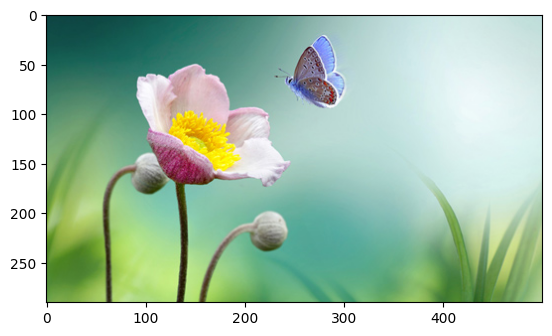

In [3]:
plt.imshow(img)
plt.show()

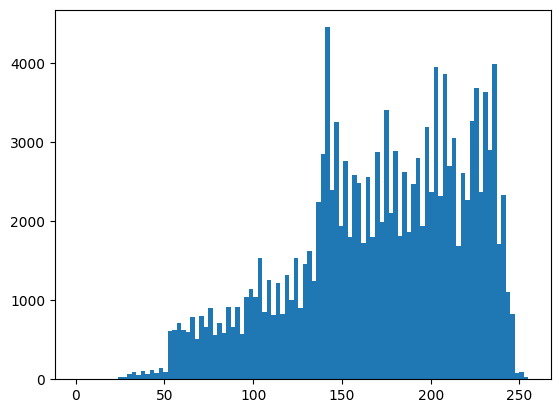

In [4]:
plt.hist(cv2.cvtColor(img,cv2.COLOR_RGB2GRAY).reshape(-1),bins=100)
plt.show()

Making rondom noise points in image in max and min values for white and black points.

In [5]:
noisy_img = np.copy(img)
h, w, c = img.shape

num_pixels = 500

# random coordinates
coords_white = [np.random.randint(0, i, num_pixels) for i in (h, w)]
coords_black = [np.random.randint(0, i, num_pixels) for i in (h, w)]

noisy_img[coords_white[0], coords_white[1]] = [255, 255, 255]
noisy_img[coords_black[0], coords_black[1]] = [0, 0, 0]

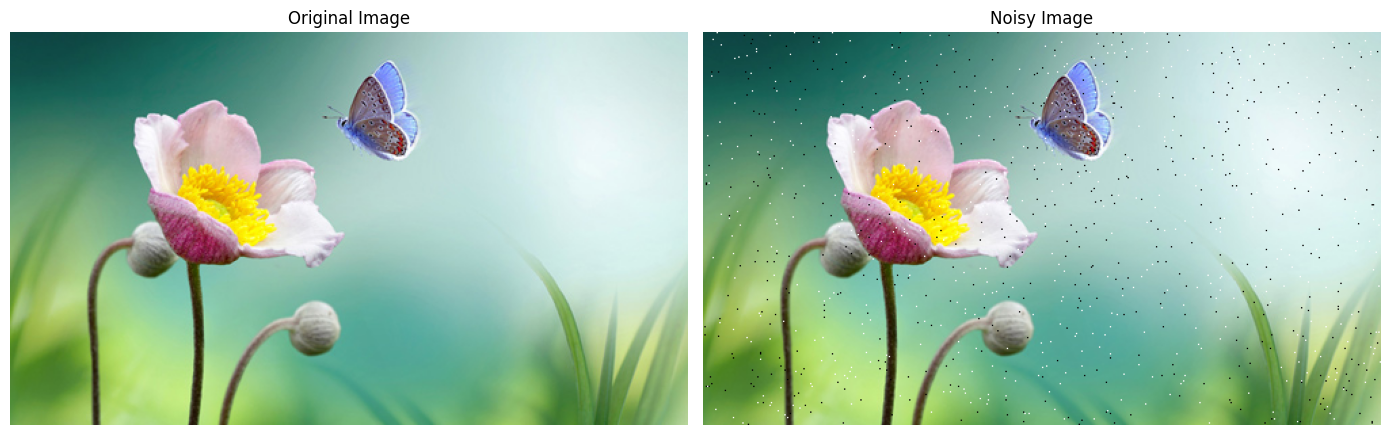

In [6]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Noisy Image')
plt.imshow(noisy_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

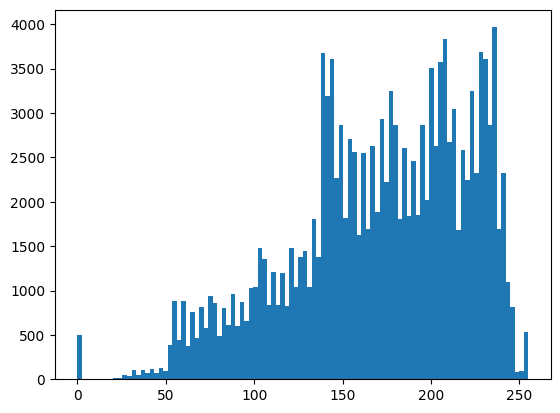

In [7]:
plt.hist(cv2.cvtColor(noisy_img,cv2.COLOR_RGB2GRAY).reshape(-1),bins=100)
plt.show()

Denoising.

Deniosing salt and pepper noise by Blur filter.

In [8]:
img_denoise = cv2.blur(noisy_img,(3,3))

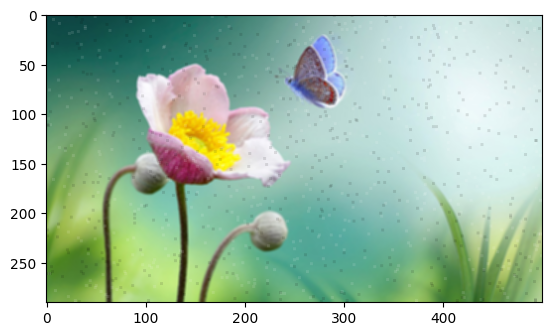

In [9]:
plt.imshow(img_denoise)
plt.show()

Now trying with Gaussian Blur.

In [10]:
img_denoise = cv2.GaussianBlur(noisy_img,(11,11),0.6)

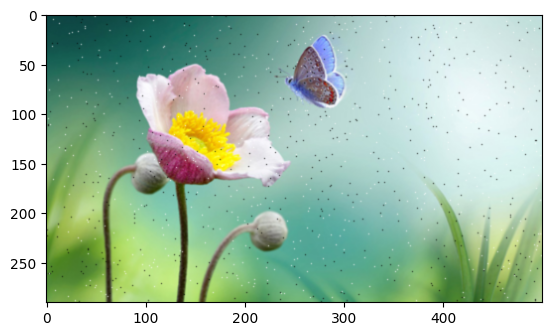

In [11]:
plt.imshow(img_denoise)
plt.show()

Now trying by Median Blur filter.

In [12]:
img_denoise = cv2.medianBlur(noisy_img,3)

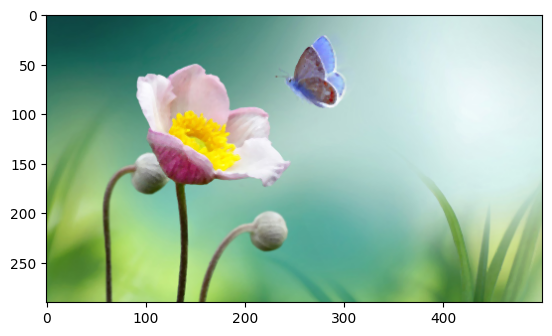

In [13]:
plt.imshow(img_denoise)
plt.show()

BilateralFilter is not a good choise for salt and pepper noise image.

In [14]:
img_denoise = cv2.bilateralFilter(noisy_img,11,sigmaColor=20,sigmaSpace=10)

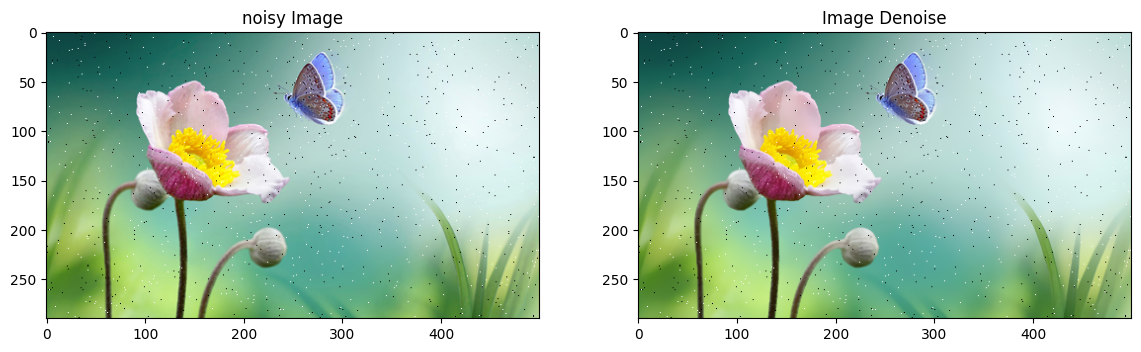

In [15]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("noisy Image")
plt.imshow(noisy_img)

plt.subplot(1, 2, 2)
plt.title("Image Denoise")
plt.imshow(img_denoise)
plt.show()